In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
%matplotlib inline

In [ ]:
housing= fetch_california_housing(as_frame=True)
df=housing.frame
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [ ]:
X = df[['MedInc']].values
y = df['MedHouseVal'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)


Train shapes: (16512, 1) (16512,)
Test shapes: (4128, 1) (4128,)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print(f"RMSE: {rmse:.6f}, MAE: {mae:.6f}")

RMSE: 0.842090, MAE: 0.629909


In [ ]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)
y_pred_poly = model_poly.predict(X_test_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
mae_poly = mean_absolute_error(y_test, y_pred_poly)
print(f"RMSE: {rmse_poly:.6f}, MAE: {mae_poly:.6f}")

RMSE: 0.838614, MAE: 0.628292


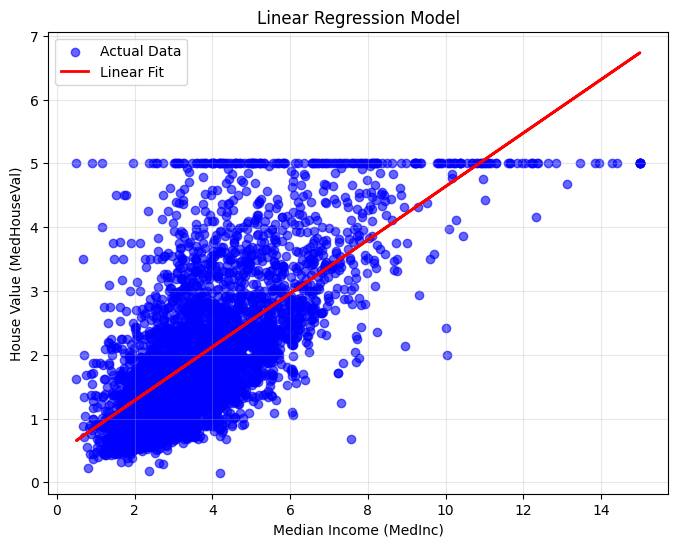

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color='blue', alpha=0.6, label='Actual Data')
plt.plot(X_test, model.predict(X_test), color='red', linewidth=2, label='Linear Fit')
plt.xlabel('Median Income (MedInc)')
plt.ylabel('House Value (MedHouseVal)')
plt.title('Linear Regression Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

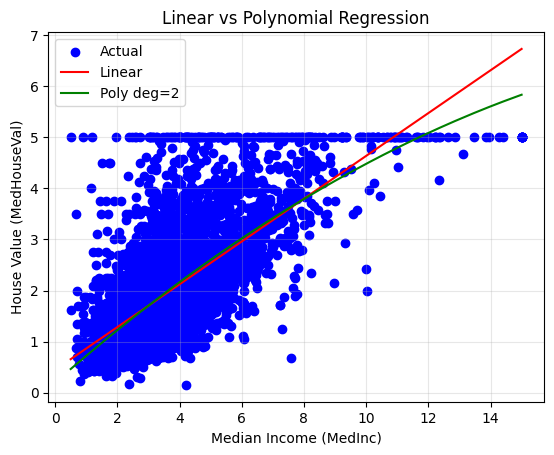

In [ ]:
plt.scatter(X_test, y_test, color='blue', label='Actual')  
plt.plot(X_test_sorted, model.predict(X_test[sort_idx]), color='red', label='Linear') 
plt.plot(X_test_sorted, model_poly.predict(X_test_poly_sorted), color='green', label='Poly deg=2')
plt.legend()
plt.xlabel('Median Income (MedInc)')
plt.ylabel('House Value (MedHouseVal)')
plt.title('Linear vs Polynomial Regression')
plt.grid(True, alpha=0.3)
plt.show()
